# Compare Gaia parallax distances with Bailer-Jones distances

This notebook cross-matches the Gaia DR3 radial-velocity sample with the Bailer-Jones et al. geometric and photogeometric distance catalog. It applies the Gaia DR3 parallax zero-point correction and compares both the corrected and uncorrected inverse-parallax distances with the tabulated photogeometric distances.

The workflow is designed for the AstroFlow Dask deployment and Gaia parquet mirrors. It expects `DASK_DATA_PATH_GAIA_DR3_SSD` to contain `GDR3_GAIA_SOURCE` and `DASK_DATA_PATH_GAIA_EDR3_SSD` to contain `GEDR3DIST`. The latter is the Gaia EDR3 distance catalog from [Bailer-Jones et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021AJ....161..147B/abstract).

Distances inferred as `1 / parallax` are expressed in kiloparsecs because Gaia parallaxes are in milliarcseconds. They are used here as diagnostics, not as recommended distance estimators for low-signal-to-noise or non-positive parallaxes.

In [1]:
from pathlib import Path
import os

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt


In [3]:
# Connect to the distributed scheduler. The default is AstroFlow-specific.
import dask.dataframe as dd
from dask.distributed import Client
scheduler_address = os.environ.get(
    'DASK_SCHEDULER_ADDRESS',
    'tcp://simple-scheduler.dask-operator.svc.cluster.local:8786',
)
c = Client(scheduler_address)
print(c)


<Client: 'tcp://172.19.205.29:8786' processes=10 threads=50, memory=700.00 GiB>


/opt/conda/lib/python3.12/site-packages/distributed/client.py:1590: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| numpy   | 2.0.2  | 2.2.6     | 2.2.6   |
| toolz   | 1.0.0  | 0.12.0    | 0.12.0  |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


In [4]:
import easy2dhist
c.upload_file("easy2dhist.py")

{'tcp://172.16.162.213:45187': {'status': 'OK'},
 'tcp://172.16.162.222:33195': {'status': 'OK'},
 'tcp://172.18.196.153:32783': {'status': 'OK'},
 'tcp://172.18.196.162:44763': {'status': 'OK'},
 'tcp://172.18.196.170:45879': {'status': 'OK'},
 'tcp://172.19.205.24:37023': {'status': 'OK'},
 'tcp://172.19.205.51:36283': {'status': 'OK'},
 'tcp://172.19.205.59:36231': {'status': 'OK'},
 'tcp://172.19.205.61:46455': {'status': 'OK'},
 'tcp://172.19.205.9:44653': {'status': 'OK'}}

In [5]:
# Install the zero-point package in the notebook and on every Dask worker.
!pip install gaiadr3-zeropoint

c.run(lambda: __import__('subprocess').run(['pip', 'install', 'gaiadr3-zeropoint'], check=True))


  Using cached gaiadr3_zeropoint-0.1.0-py3-none-any.whl.metadata (3.5 kB)
Using cached gaiadr3_zeropoint-0.1.0-py3-none-any.whl (11 kB)


{'tcp://172.16.162.213:45187': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.16.162.222:33195': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.153:32783': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.162:44763': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.18.196.170:45879': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.24:37023': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.51:36283': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.59:36231': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.61:46455': CompletedProcess(args=['pip', 'install', 'gaiadr3-zeropoint'], returncode=0),
 'tcp://172.19.205.9:44

## Load and select the distributed catalogs

The Gaia table is restricted to sources with radial velocities, while the distance table is restricted to rows with a finite median photogeometric distance. Only Gaia columns needed for the zero-point correction and subsequent diagnostics are retained before the cross-match. Persisting these filtered tables avoids repeating the same scans in later distributed operations.

In [6]:
_t1 = time.time()

gaia_root = os.environ.get('DASK_DATA_PATH_GAIA_DR3_SSD')
distance_root = os.environ.get('DASK_DATA_PATH_GAIA_EDR3_SSD')
if not gaia_root or not distance_root:
    raise ValueError(
        'Set DASK_DATA_PATH_GAIA_DR3_SSD and DASK_DATA_PATH_GAIA_EDR3_SSD.'
    )

gaia_source = dd.read_parquet(
    Path(gaia_root).joinpath('GDR3_GAIA_SOURCE'), engine='pyarrow'
)
dist_table = dd.read_parquet(
    Path(distance_root).joinpath('GEDR3DIST'), engine='pyarrow'
)

print(f'Time elapsed: {time.time() - _t1:.1f} s')

# Distance columns include r_med_geo and r_med_photogeo, in parsecs.

Time elapsed:  0.3721163272857666


In [7]:

# Select sources with a reported radial velocity.
gaia_source = gaia_source[
    gaia_source["radial_velocity"].notnull()
].persist()


In [8]:



# Keep sources with a valid median photogeometric distance.
dist_table = dist_table[dist_table["r_med_photogeo"].notnull()].persist()

In [9]:

astrometric_features = [
    'source_id',
    'ra',
    'dec',
    # Distance diagnostics
    'parallax', 'parallax_error', 'parallax_over_error',
    # RVS sample selection
    'radial_velocity', 'radial_velocity_error',
    # Inputs required by gaiadr3-zeropoint
    'phot_g_mean_mag',
    'nu_eff_used_in_astrometry',
    'pseudocolour',
    'ecl_lat',
    'astrometric_params_solved',
    # Quality-control and reproducible-sampling columns
    'ruwe',
    'random_index',
]

# Reduce the persisted Gaia table before the cross-match.
gaia_source = gaia_source[astrometric_features].persist()


In [10]:
def join_partition(left, right):
    return left.merge(right, on="source_id", how="inner")

partitions_are_aligned = (
    gaia_source.npartitions == dist_table.npartitions
    and gaia_source.known_divisions
    and dist_table.known_divisions
    and gaia_source.divisions == dist_table.divisions
)

if partitions_are_aligned:
    # Fast path: matching source_id divisions make pairwise joins safe.
    result = gaia_source.map_partitions(join_partition, dist_table)
else:
    # Correct fallback when parquet partition boundaries do not match.
    result = gaia_source.merge(dist_table, on='source_id', how='inner')

## Cross-match the catalogs

The join is lazy. A pairwise partition join avoids a shuffle only when both inputs have identical, known `source_id` divisions. If that condition is not met, the notebook falls back to Dask's standard merge so that sources in different parquet partitions are not silently missed.

In [12]:
_t1 = time.time()

# This measures graph construction only; execution occurs with compute() below.
print(f'Join graph constructed in {time.time() - _t1:.3f} s')


Time elapsed:  7.295608520507812e-05


## Apply the Gaia DR3 parallax zero-point correction

The `gaiadr3-zeropoint` model uses G magnitude, astrometric colour information, ecliptic latitude, and the astrometric solution type. Its correction is in milliarcseconds, matching the Gaia `parallax` column, so the corrected value is `parallax - zeropoint`. The package clips inputs outside its calibrated ranges and emits warnings when this occurs; those sources should be treated cautiously.

In [13]:
def get_parallax_zeropoints(partition):
    from zero_point import zpt
    # Initialize the coefficient tables once per worker process (subsequent calls are cached).
    zpt.load_tables()

    phot_g_mean_mag = partition['phot_g_mean_mag'].values
    nu_eff_used_in_astrometry = partition['nu_eff_used_in_astrometry'].values
    pseudocolour = partition['pseudocolour'].values
    ecl_lat = partition['ecl_lat'].values
    astrometric_params_solved = partition['astrometric_params_solved'].values

    zeropoint = zpt.get_zpt(
        phot_g_mean_mag, nu_eff_used_in_astrometry, pseudocolour,
        ecl_lat, astrometric_params_solved,
    )
    partition = partition.copy()
    partition['zeropoint'] = zeropoint
    partition['parallax_corrected'] = partition['parallax'] - partition['zeropoint']

    return partition

In [15]:
# Use one real partition to construct accurate Dask metadata.
_time1 = time.time()

sample = result.get_partition(0).compute()
meta = get_parallax_zeropoints(sample).iloc[:0]  # empty df with correct columns/dtypes

result2 = result.map_partitions(get_parallax_zeropoints, meta=meta)

# Materialize the full corrected cross-match as a local pandas DataFrame.
smalldf_pd = result2.compute()

print(f'Elapsed time: {time.time() - _time1:.1f} s')



/opt/conda/lib/python3.12/site-packages/zero_point/zpt.py:215: UserWarning: The apparent magnitude of one or more of the sources is outside the expected range (6-21 mag). 
                Outside this range, there is no further interpolation, thus the values at 6 or 21 are returned.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zero_point/zpt.py:243: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


Elapsed time 192.54812049865723


In [16]:
output_path = Path('data/rvs_joined_bailerjones.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)
smalldf_pd.to_parquet(output_path, engine='pyarrow', compression='zstd')

# Optional restart point: read the checkpoint instead of recomputing the join.
smalldf_pd = pd.read_parquet(output_path, engine='pyarrow')

print(smalldf_pd['r_med_photogeo'].size)

33581727


## Compare inverse-parallax and photogeometric distances

The following density plots use `easy2dhist` to compare inverse-parallax distances with the Bailer-Jones median photogeometric distance. The vertical axis is the fractional residual `(inverse-parallax distance - photogeometric distance) / photogeometric distance`; zero indicates agreement. The first plot uses zero-point-corrected parallaxes and the second uses the catalog parallaxes unchanged.

(33581727,)


/tmp/ipykernel_1363/1678779525.py:17: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


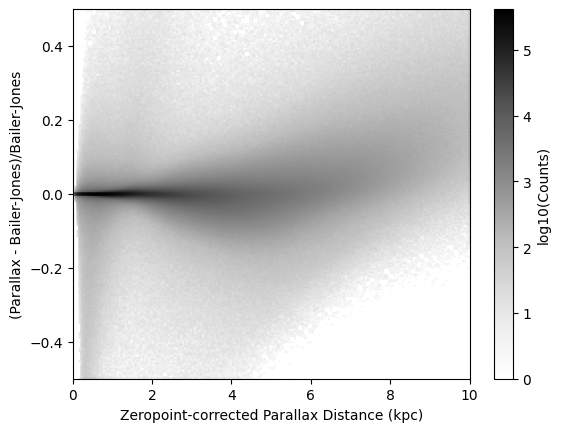

In [18]:
inverse_parallax_distance = 1.0 / smalldf_pd['parallax_corrected']
photogeometric_distance = smalldf_pd['r_med_photogeo'] / 1000.0
fractional_residual = (
    (inverse_parallax_distance - photogeometric_distance)
    / photogeometric_distance
)
print(inverse_parallax_distance.shape)

# 1. Define your ranges
x_bounds = (0, 10)
y_bounds = (-0.5, 0.5)

# 2. Generate the histogram
H, xe, ye = easy2dhist.hist2d_raw(
    inverse_parallax_distance, fractional_residual,
    bins=(200, 200), xrange=x_bounds, yrange=y_bounds,
)

# 3. Create the extent tuple: [xmin, xmax, ymin, ymax]
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

# 4. Plot with extent and proper origin alignment
plt.imshow(
    np.ma.log10(np.ma.masked_equal(H.T, 0)),
    extent=plot_extent, 
    origin='lower', 
    aspect='auto',
    cmap='Greys'
)
plt.xlabel('Zeropoint-corrected Parallax Distance (kpc)')
plt.ylabel('(Parallax - Bailer-Jones)/Bailer-Jones')

plt.title('Zero-point-corrected parallax')
plt.colorbar(label='log10(Counts)')
plt.tight_layout()
plt.show()

(33581727,)


/tmp/ipykernel_1363/1721993085.py:17: RuntimeWarning: divide by zero encountered in log10
  np.log10(H.T),


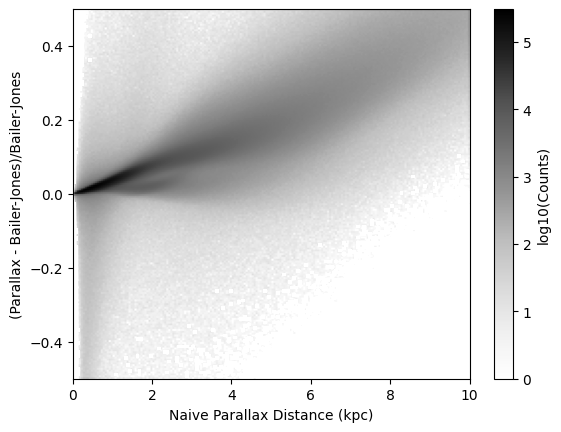

In [19]:
inverse_parallax_distance = 1.0 / smalldf_pd['parallax']
photogeometric_distance = smalldf_pd['r_med_photogeo'] / 1000.0
fractional_residual = (
    (inverse_parallax_distance - photogeometric_distance)
    / photogeometric_distance
)
print(inverse_parallax_distance.shape)

# 1. Define your ranges
x_bounds = (0, 10)
y_bounds = (-0.5, 0.5)

# 2. Generate the histogram
H, xe, ye = easy2dhist.hist2d_raw(
    inverse_parallax_distance, fractional_residual,
    bins=(200, 200), xrange=x_bounds, yrange=y_bounds,
)

# 3. Create the extent tuple: [xmin, xmax, ymin, ymax]
plot_extent = [x_bounds[0], x_bounds[1], y_bounds[0], y_bounds[1]]

# 4. Plot with extent and proper origin alignment
plt.imshow(
    np.ma.log10(np.ma.masked_equal(H.T, 0)),
    extent=plot_extent, 
    origin='lower', 
    aspect='auto',
    cmap='Greys'
)
plt.xlabel('Naive Parallax Distance (kpc)')
plt.ylabel('(Parallax - Bailer-Jones)/Bailer-Jones')

plt.title('Uncorrected Gaia catalog parallax')
plt.colorbar(label='log10(Counts)')
plt.tight_layout()
plt.show()

## Interpretation notes

Differences between these panels isolate the effect of the Gaia parallax zero-point correction within the selected RVS cross-match. They do not constitute a general validation of either distance estimator: inverse parallax becomes biased and unstable at low signal-to-noise, while photogeometric distances incorporate a Galactic prior and photometric information. Selection on available radial velocity and valid `r_med_photogeo` also means that this sample is not representative of the full Gaia catalog.